In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Números Pseudo-aleatorios

Computacionalmente, simular números 100% aleatorios es casi imposible, actualmente existen técnicas cuánticas para aproximarlos, en el caso de Python se pueden generar *números pseudo-aleatorios*, donde el apodo pseudo viene por el echo que siempre que intentemos aproximar un números aleatorios computacionalmente, estos generarán patrones eventualmente.

Python mediante la libreria *numpy* posee funciones sencillas para simularlos como se puede observar a continuación:

In [8]:
# Generar números pseudo-aleatorios entre 0 y 1

n = 10

np.random.random(n)

array([0.28176626, 0.01703364, 0.92156796, 0.5932117 , 0.79275194,
       0.73193675, 0.28421781, 0.11662894, 0.49578427, 0.16190342])

In [11]:
# Generar números de una distribución normal
for i in range(10):
  print(np.random.normal(i))

1.155437621543506
-0.3414310396146325
1.997258527607433
3.291495911412251
3.2200356707206748
4.765878095785408
6.851702596258692
6.3045962715240105
8.40621256849358
9.515272158216618


In [13]:
# Generar números de una distribución Binomial

p = 0.5 # Probabilidad de éxito

for i in range(10):
  print(np.random.binomial(i,p))

0
0
1
2
2
3
3
3
2
7


# Simulación Monte Carlo

Las simulaciones Monte Carlo están basadas principalmente en la Ley de los Grandes Números (LGN)


$$
   \dfrac{S_n}{n} = \dfrac{1}{n} \sum_{i=1}^{n}X_i \xrightarrow{\hspace{0.5cm} \mathbb P\backslash c.s\hspace{0.5cm}} \mu,
$$
quue nos dice que podemos aproximar el valor esperado $\mu = \mathbb E[X]$ de alguna distribución $X \sim \mathbb P$, utilizando la media muestral $S_n/n$ cuando $n \to+\infty $.
También el Teorema Central del Límite:


$$
  \sqrt{n} \dfrac{ \hat{\theta}_n - \theta }{\sqrt{\sigma^2}} \xrightarrow{\hspace{0.5cm} \mathcal L \hspace{0.5cm}} \mathcal N(0,1)
$$
 de manera naïve, al estandarizar cualquier distribución de probabilidad, converge en ley a una distribución normal estándar.


In [ ]:
#Estimación de parámetros básicos

datos = np.array([2, 4, 4, 4, 5, 5, 7, 9])

n = len(datos)
media = np.mean(datos)

suma_cuadrados = np.sum((datos - media)**2)
varianza_muestral = suma_cuadrados / (n - 1)

print("n =", n)
print("media =", media)
print("suma de cuadrados =", suma_cuadrados)
print("varianza muestral =", varianza_muestral)

n = 8
media = 5.0
suma de cuadrados = 32.0
varianza muestral = 4.571428571428571


En este ejemplo aproximaremos la probabilidad de una distribución normal estándar, por ejemplo:

Para $Z \sim \mathcal N(0,1)$, calcularemos:
$$
  \mathbb P (Z > c),
$$

utilizando una simulación Monte Carlo.



In [5]:

# Simulacion de p(X > 1.5) para X que sigue N(0,1)

N = 10000 #Cantidad de datos muestrales que samplearemos de una normal estándar

c = 1.5 # Umbral inferior de los valores de Z que consideraremos para estimar la probabilidad

samples = np.random.normal(loc=0, scale=1, size = N) #loc = media, scale = varianza

I = samples > c # Condición para ser un caso favorable

prob = np.mean(I) # Promediamos de forma empírica

print(prob)

#Genericemosla como una función

def prob_normalest(media, varianza, N, semilla=None):
  if semilla is not None:
    np.random.seed(semilla)

  sim = np.random.normal(loc=media, scale= varianza, size = N)
  estimacion = np.mean(sim > c)
  return estimacion

result = prob_normalest(0, 1, 1000, 123)
print(result)

0.071
0.066


#Movimiento Browniano estándar
Para simular una trayectoria de un movimiento browniano estándar (MBE):

$$
  B = (B_t)_{t\geq 0}, \quad B_t \sim \mathcal N(0,t)
$$

 nos aprovechamos de la siguiente equivalencia:


$$
  B_{t} \sim \mathcal N (0,t) \iff \sqrt{t}\ \mathcal N(0,1),
$$

dado que en Python es sencillo simular valores aleatorios provenientes de una distribución normal estándar, recordando que el MBE satisface:


* $B_0 = 0.$
*   (**Incrementos independientes**): Para tiempos $t_0, \ldots , t_n$, los incrementos:
  $$ B_{t_1} - B_{t_0}, B_{t_2} - B_{t_1}, \ldots , B_{t_{n}}-B_{t_{n-1}}$$
  son independientes.
*   (**Trayectorias continuas**): Para $\omega \in \Omega$ fijo, la trayectoria $t \mapsto B_{t}(\omega)$ es continua casi seguramente.

$$
  B_{i+1} = B_i + \sqrt{\delta t}\ \xi_i
$$
donde $\xi_i$ es un sample de una $\mathcal N(0,1)$ y $\delta t = T/N$. Con $T$ tiempo final del proceso, $N$ un valor entero que refina la malla.



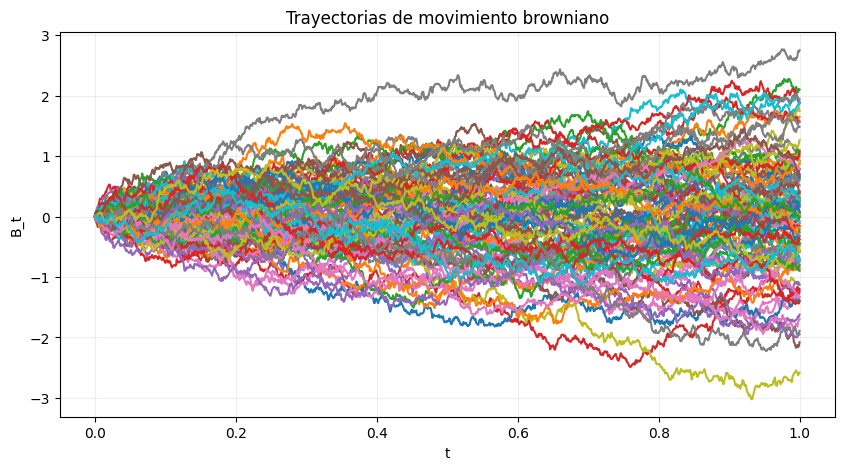

In [6]:
T = 1.0
n = 1000
cantidad_trayectorias = 100
delta_t = T / n #tamaño de cada tramo de la malla
tiempos = np.linspace(0, T, n + 1) #malla

plt.figure(figsize=(10, 5))

for _ in range(cantidad_trayectorias):
    incrementos = np.sqrt(delta_t) * np.random.randn(n) # B_{i+1} = B_{i} + \delta(t)* N(0,1)
    trayectoria = np.concatenate(([0], np.cumsum(incrementos))) #armamos trayectoria suave
    plt.plot(tiempos, trayectoria)

plt.xlabel("t")
plt.ylabel("B_t")
plt.title("Trayectorias de movimiento browniano")
plt.grid(True, alpha=0.2)
plt.savefig("browniano.png",dpi=300)
plt.show()